In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Set plotting style
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['figure.titleweight'] = 'bold'


In [2]:
def create_simple_bar_chart(df, x_column, y_column, title=None, ylabel=None, width=0.6):
    """
    Create a simple bar chart for SUMO data (single series, no algorithms).
    """
    # Sort by x_column with custom order for traffic levels
    if x_column == 'Traffic':
        order = {'Low': 0, 'Mid': 1, 'High': 2}
        df_sorted = df.copy()
        df_sorted['_sort'] = df_sorted[x_column].map(order)
        df_sorted = df_sorted.sort_values('_sort').drop('_sort', axis=1)
    else:
        df_sorted = df.sort_values(x_column)
    
    x_values = df_sorted[x_column].values
    y_values = df_sorted[y_column].values
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Use categorical positions for consistent bar widths
    x_positions = np.arange(len(x_values))
    
    # Create bars with specified width
    bars = ax.bar(
        x_positions,
        y_values,
        width=width,
        color='#1f77b4',  # Blue color
        edgecolor='black',
        linewidth=0.5,
    )
    
    # Add value labels on top of bars
    for bar, val in zip(bars, y_values):
        height = bar.get_height()
        if val < 10:
            label_text = f"{val:.2f}"
        elif val < 100:
            label_text = f"{val:.1f}"
        else:
            label_text = f"{int(val)}"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            label_text,
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='normal',
        )
    
    # Customize axes - use categorical labels
    ax.set_xlabel(x_column, fontweight='bold')
    ax.set_ylabel(ylabel or y_column, fontweight='bold')
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_values)
    
    # Calculate smart y-axis range to make differences visible
    y_min = min(y_values)
    y_max = max(y_values)
    y_range = y_max - y_min
    if y_min > 0 and y_range > 0:
        if y_min > y_range * 0.5:
            y_bottom = max(0, y_min * 0.95)
        else:
            y_bottom = max(0, y_min - (y_range * 0.1))
        ax.set_ylim(bottom=y_bottom, top=y_max * 1.05)
    else:
        ax.set_ylim(bottom=0, top=y_max * 1.05)
    
    # Add grid
    ax.grid(True, axis='y', linestyle='--', linewidth=0.5, alpha=0.7, color='gray')
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    return fig, ax


In [3]:
# Load data
base_path = Path.cwd()
if base_path.name == 'viz':
    base_path = base_path.parent

# Load Traffic data
df_traffic = pd.read_csv(base_path / 'data_sumo_static2' / 'traffic.csv')
print("Traffic Data:")
print(df_traffic)


Traffic Data:
  Traffic  Total Travel Time  Total Energy Consumed  Total Distance Covered  \
0     Low              99.77                  9.391                   67.15   
1     Mid             109.51                  8.793                   64.80   
2    High             118.14                  8.118                   59.78   

   Run Time  Total Module Swapped  
0         0                     0  
1         0                     0  
2         0                     0  


# Sumo Static 2 Traffic


## (a) Travel Time


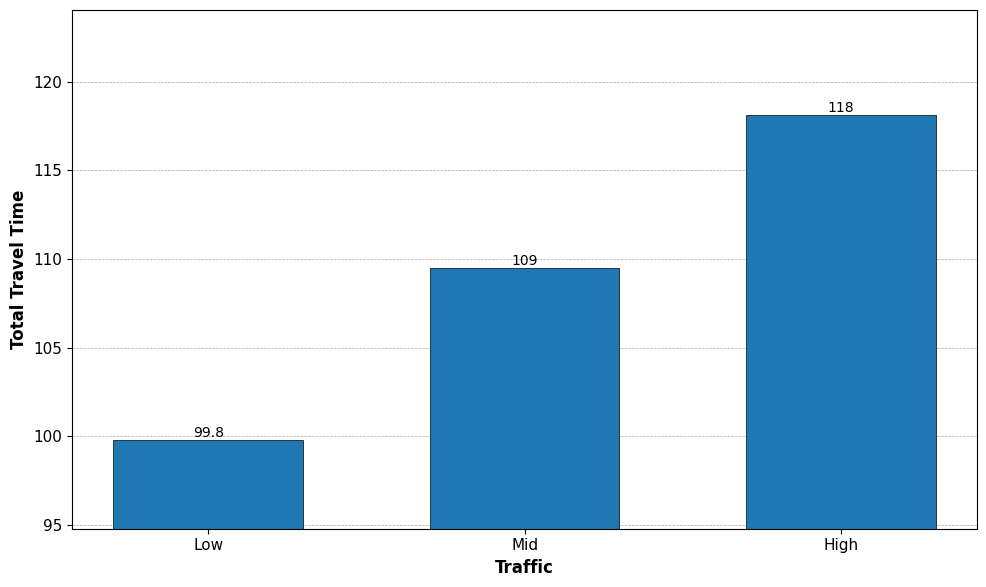

In [4]:
# Traffic - Travel Time
fig, ax = create_simple_bar_chart(
    df_traffic,
    'Traffic',
    'Total Travel Time',
    ylabel='Total Travel Time'
)
plt.show()


## (b) Energy


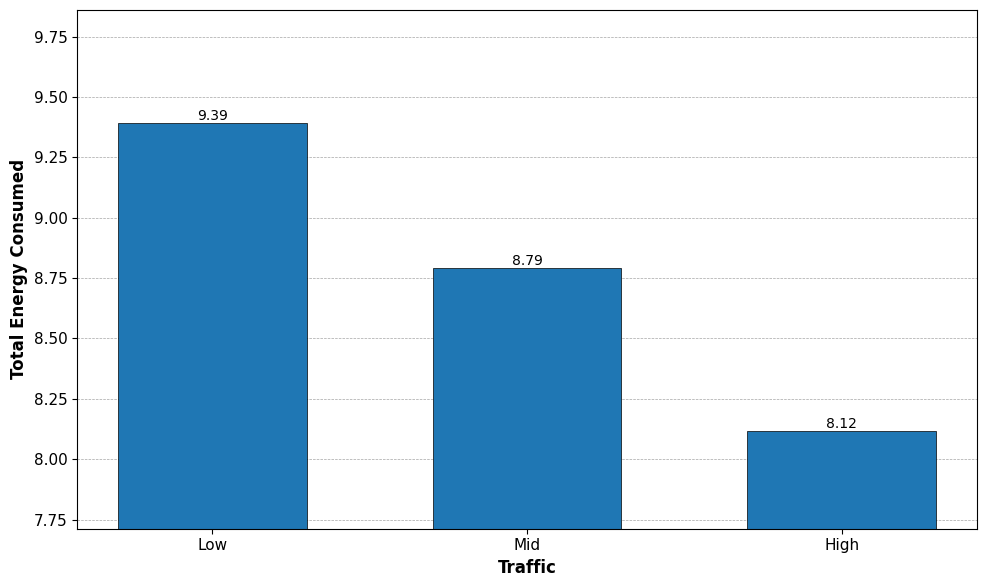

In [5]:
# Traffic - Energy
fig, ax = create_simple_bar_chart(
    df_traffic,
    'Traffic',
    'Total Energy Consumed',
    ylabel='Total Energy Consumed'
)
plt.show()


## (c) Distance


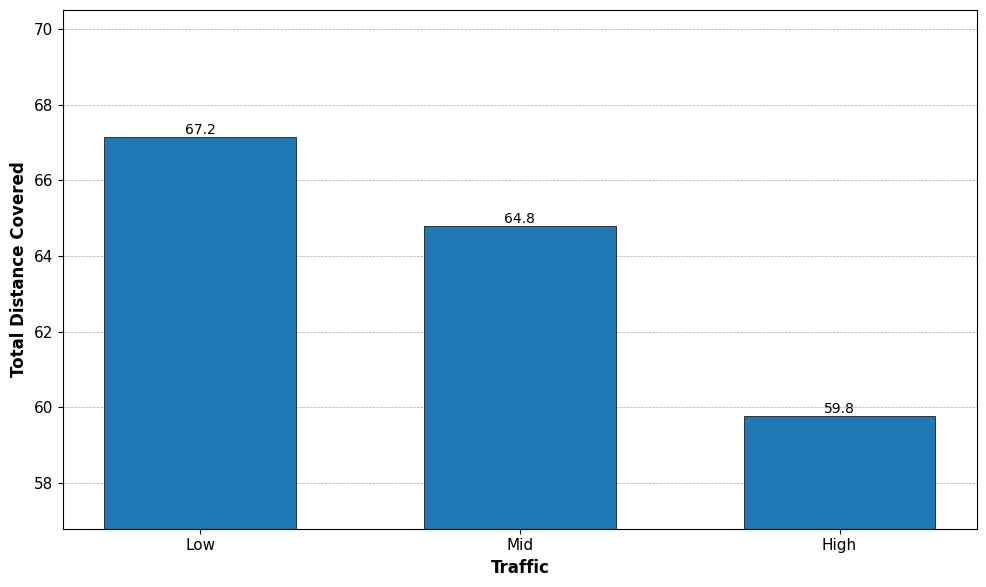

In [6]:
# Traffic - Distance
fig, ax = create_simple_bar_chart(
    df_traffic,
    'Traffic',
    'Total Distance Covered',
    ylabel='Total Distance Covered'
)
plt.show()


## (d) Module Swapped


C:\Users\ranji\AppData\Local\Temp\ipykernel_32272\3136205628.py:69: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(bottom=0, top=y_max * 1.05)


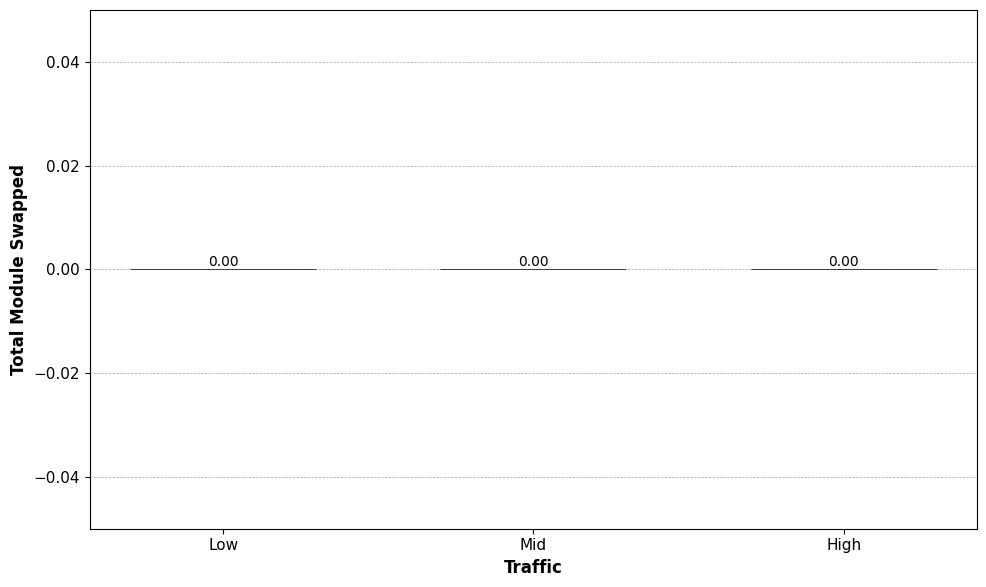

In [7]:
# Traffic - Module Swapped
fig, ax = create_simple_bar_chart(
    df_traffic,
    'Traffic',
    'Total Module Swapped',
    ylabel='Total Module Swapped'
)
plt.show()


## (e) Run Time


C:\Users\ranji\AppData\Local\Temp\ipykernel_32272\3136205628.py:69: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(bottom=0, top=y_max * 1.05)


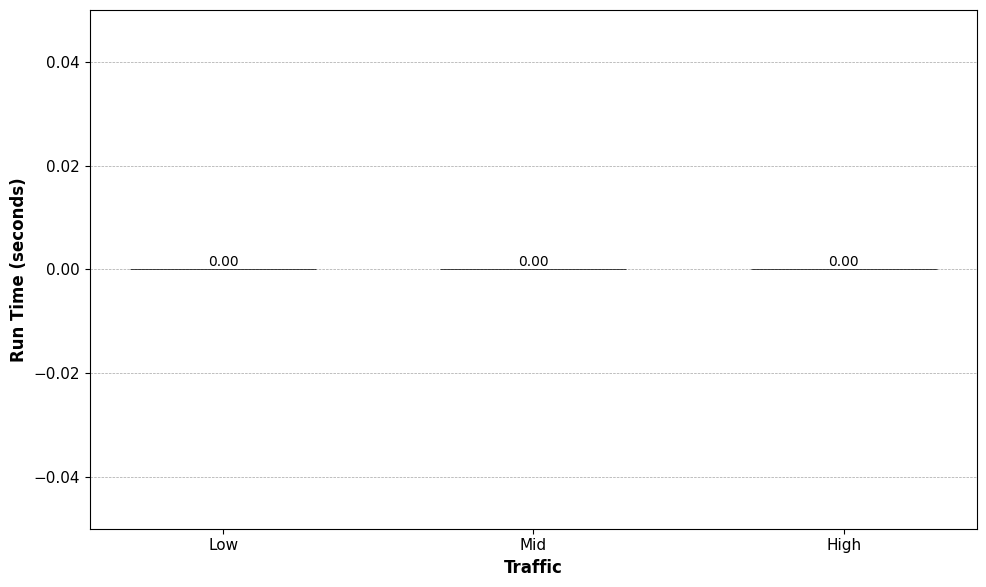

In [8]:
# Traffic - Run Time
fig, ax = create_simple_bar_chart(
    df_traffic,
    'Traffic',
    'Run Time',
    ylabel='Run Time (seconds)'
)
plt.show()


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Set plotting style
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['figure.titleweight'] = 'bold'

In [10]:
def create_simple_bar_chart(df, x_column, y_column, title=None, ylabel=None, width=0.6):
    """
    Create a simple bar chart for SUMO data (single series, no algorithms).
    """
    # Sort by x_column
    df_sorted = df.sort_values(x_column)
    x_values = df_sorted[x_column].values
    y_values = df_sorted[y_column].values
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Use categorical positions for consistent bar widths
    x_positions = np.arange(len(x_values))
    
    # Create bars with specified width
    bars = ax.bar(
        x_positions,
        y_values,
        width=width,
        color='#1f77b4',  # Blue color
        edgecolor='black',
        linewidth=0.5,
    )
    
    # Add value labels on top of bars
    for bar, val in zip(bars, y_values):
        height = bar.get_height()
        if val < 10:
            label_text = f"{val:.2f}"
        elif val < 100:
            label_text = f"{val:.1f}"
        else:
            label_text = f"{int(val)}"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            label_text,
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='normal',
        )
    
    # Customize axes - use categorical labels
    ax.set_xlabel(x_column, fontweight='bold')
    ax.set_ylabel(ylabel or y_column, fontweight='bold')
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_values)
    
    # Calculate smart y-axis range to make differences visible
    y_min = min(y_values)
    y_max = max(y_values)
    y_range = y_max - y_min
    if y_min > 0 and y_range > 0:
        if y_min > y_range * 0.5:
            y_bottom = max(0, y_min * 0.95)
        else:
            y_bottom = max(0, y_min - (y_range * 0.1))
        ax.set_ylim(bottom=y_bottom, top=y_max * 1.05)
    else:
        ax.set_ylim(bottom=0, top=y_max * 1.05)
    
    # Add grid
    ax.grid(True, axis='y', linestyle='--', linewidth=0.5, alpha=0.7, color='gray')
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    return fig, ax

In [11]:
# Load data
base_path = Path.cwd()
if base_path.name == 'viz':
    base_path = base_path.parent

# Load Threshold data
df_threshold = pd.read_csv(base_path / 'data_sumo_static2' / 'sumo_static _Threshold.csv')
print("Threshold Data:")
print(df_threshold)
print()

# Load Swap Time data
df_swaptime = pd.read_csv(base_path / 'data_sumo_static2' / 'sumo_static_SwappingTime.csv')
print("Swap Time Data:")
print(df_swaptime)
print()

# Load Module Change data
df_modulechange = pd.read_csv(base_path / 'data_sumo_static2' / 'sumo_static_ModuleChange.csv')
print("Module Change Data:")
print(df_modulechange)

Threshold Data:
   Threshold  Total Travel Time  Total Energy Consumed  \
0          5             106.44                 11.338   
1         10             105.54                 10.997   
2         15             104.01                 10.886   
3         20              92.73                  9.051   

   Total Distance Covered  Run Time  Total Module Swapped  
0                   69.18    51.827                     0  
1                   68.14    49.431                     0  
2                   67.32    43.774                     0  
3                   57.52    41.297                     0  

Swap Time Data:
   Swap Time (min)  Total Travel Time  Total Energy Consumed  \
0                1             100.69                   11.0   
1                2             100.69                   11.0   
2                3             100.69                   11.0   
3                4             100.69                   11.0   

   Total Distance Covered  Run Time  Total Module Swapp

# Sumo Static 2 Threshold

## (a) Travel Time

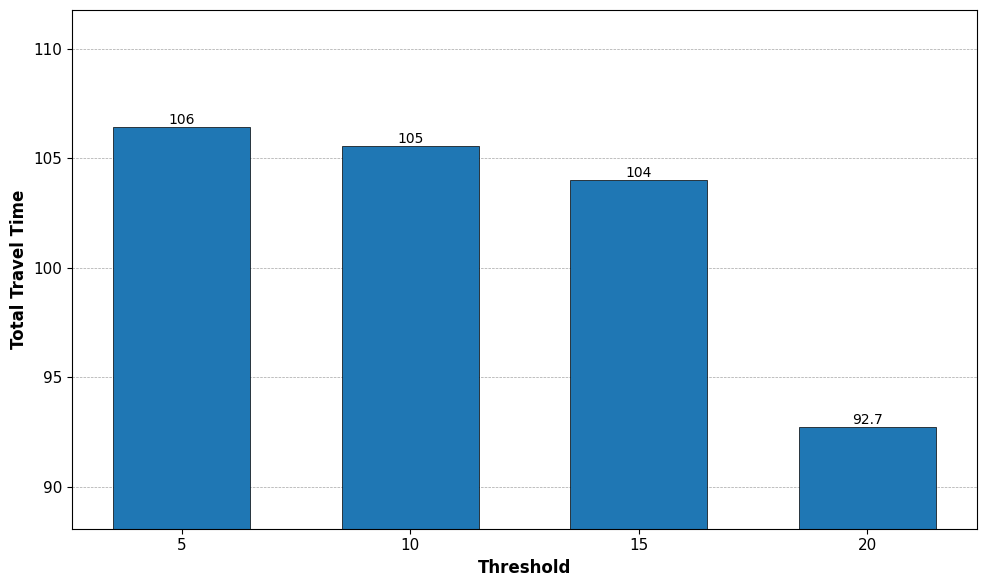

In [12]:
# Threshold - Travel Time
fig, ax = create_simple_bar_chart(
    df_threshold,
    'Threshold',
    'Total Travel Time',
    ylabel='Total Travel Time'
)
plt.show()

## (b) Energy

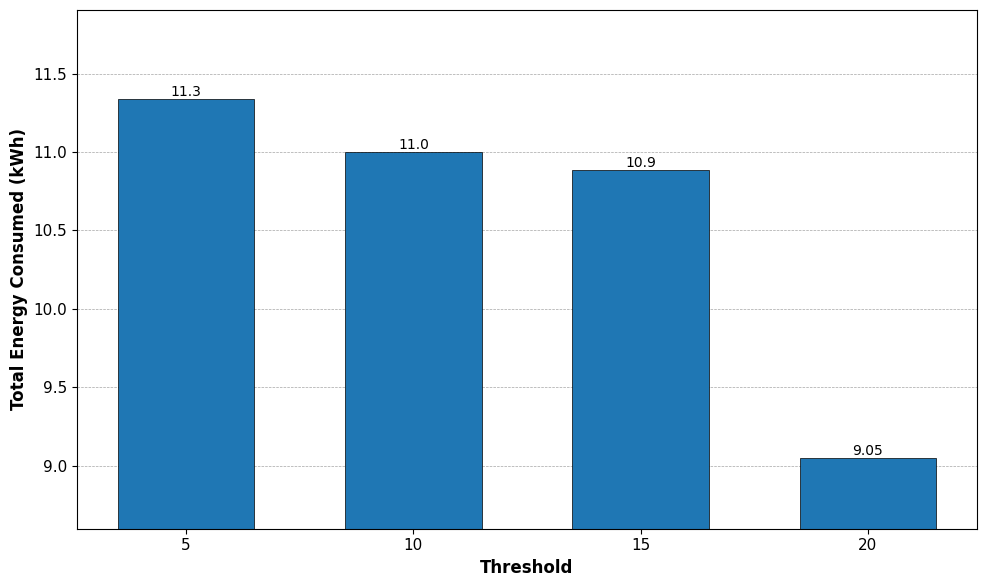

In [13]:
# Threshold - Total Energy Consumed
fig, ax = create_simple_bar_chart(
    df_threshold,
    'Threshold',
    'Total Energy Consumed',
    ylabel='Total Energy Consumed (kWh)'
)
plt.show()

## (c) Distance

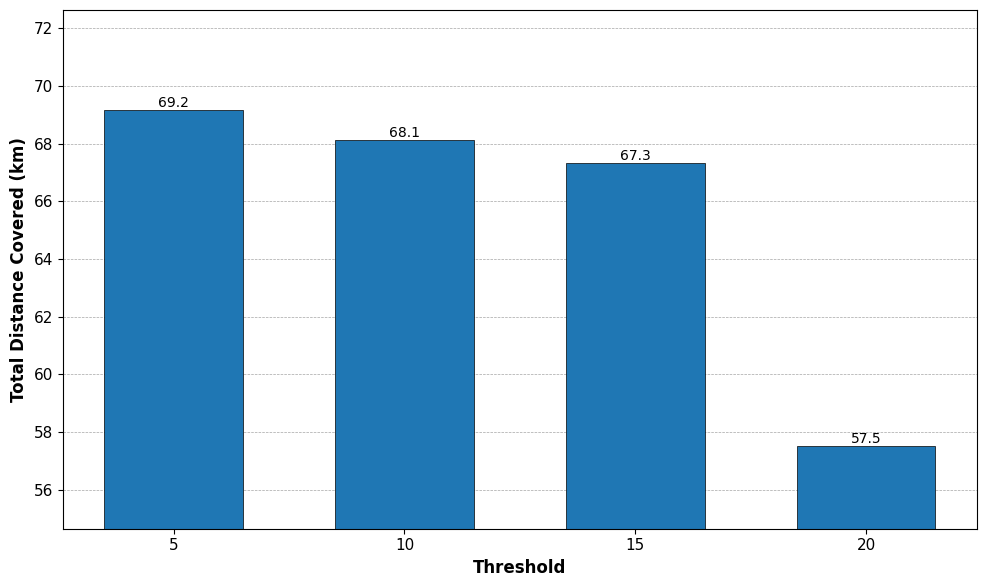

In [14]:
# Threshold - Total Distance Covered
fig, ax = create_simple_bar_chart(
    df_threshold,
    'Threshold',
    'Total Distance Covered',
    ylabel='Total Distance Covered (km)'
)
plt.show()

## (d) Run Time

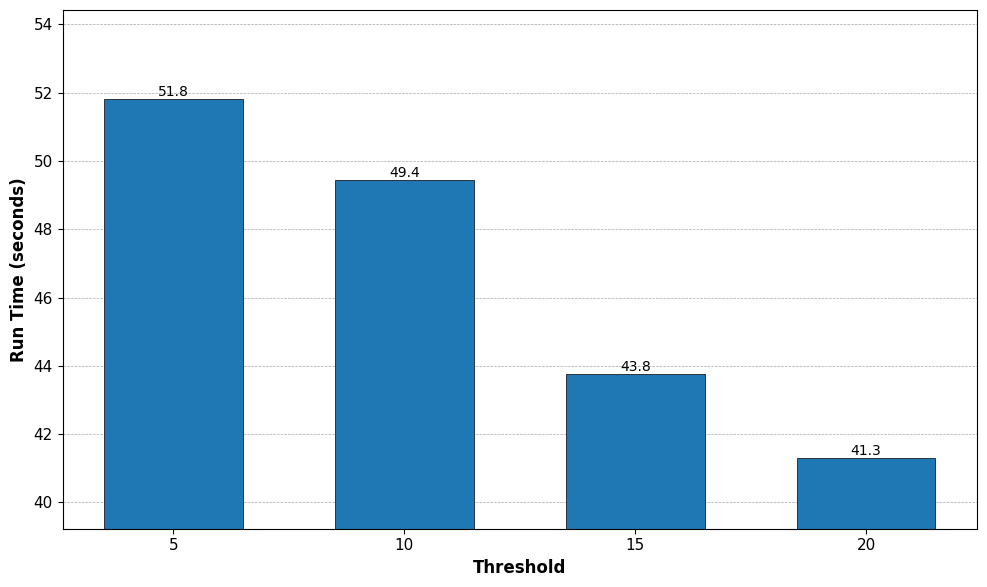

In [15]:
# Threshold - Run Time
fig, ax = create_simple_bar_chart(
    df_threshold,
    'Threshold',
    'Run Time',
    ylabel='Run Time (seconds)'
)
plt.show()

# Sumo Static 2 Module Change

## (a) Travel Time

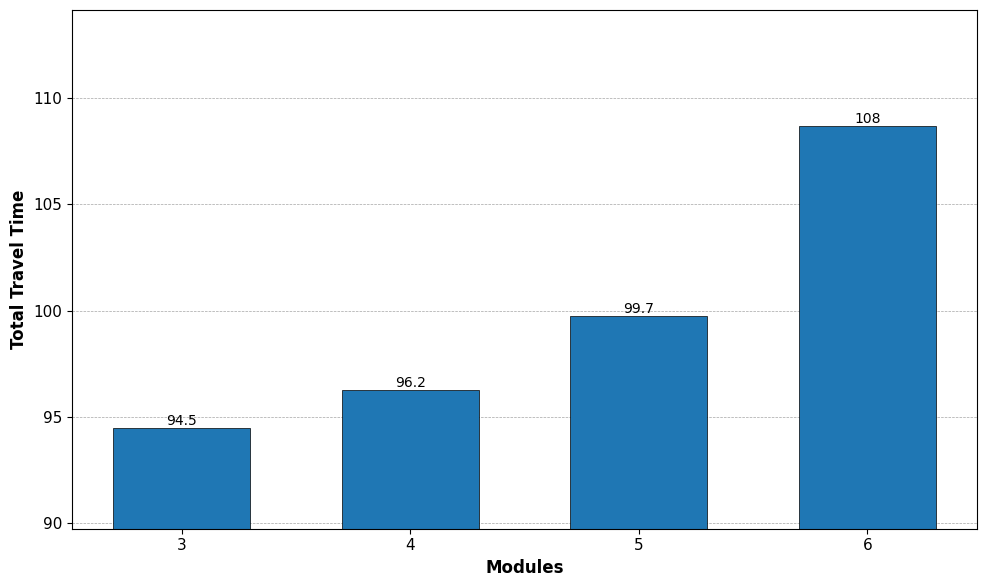

In [16]:
# Module Change - Travel Time
fig, ax = create_simple_bar_chart(
    df_modulechange,
    'Modules',
    'Total Travel Time',
    ylabel='Total Travel Time'
)
plt.show()

## (b) Energy

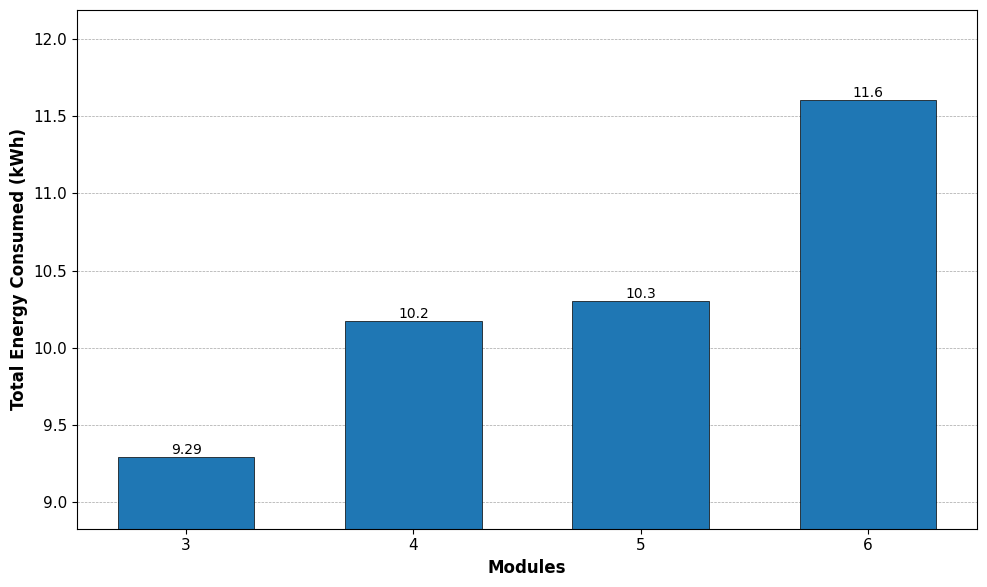

In [17]:
# Module Change - Total Energy Consumed
fig, ax = create_simple_bar_chart(
    df_modulechange,
    'Modules',
    'Total Energy Consumed',
    ylabel='Total Energy Consumed (kWh)'
)
plt.show()

## (c) Distance

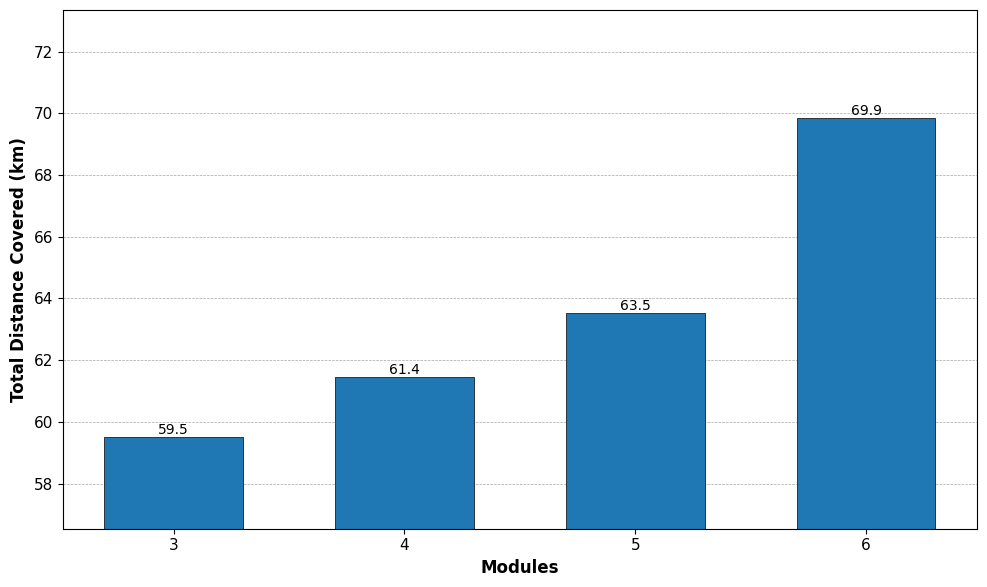

In [18]:
# Module Change - Total Distance Covered
fig, ax = create_simple_bar_chart(
    df_modulechange,
    'Modules',
    'Total Distance Covered',
    ylabel='Total Distance Covered (km)'
)
plt.show()

## (d) Run Time

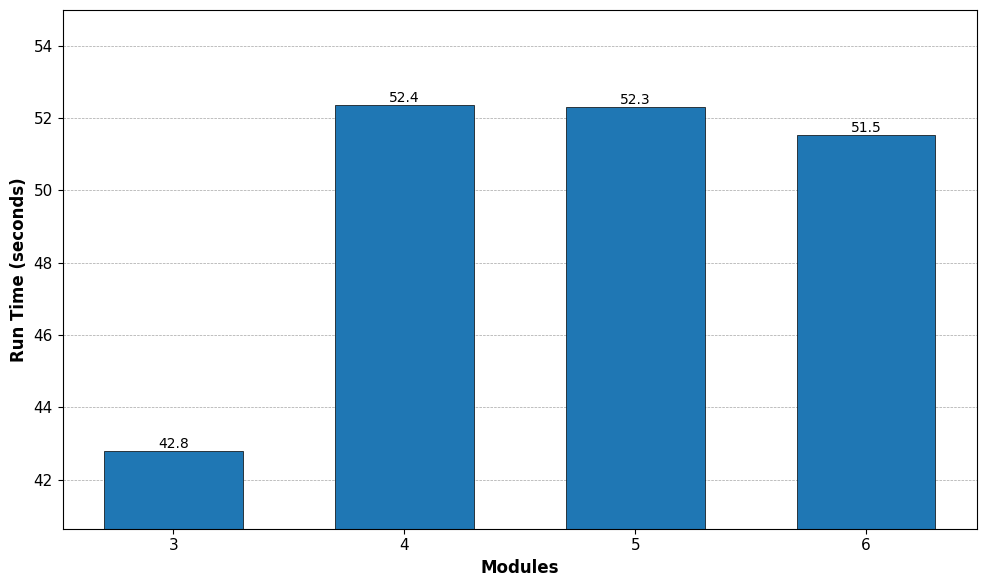

In [19]:
# Module Change - Run Time
fig, ax = create_simple_bar_chart(
    df_modulechange,
    'Modules',
    'Run Time',
    ylabel='Run Time (seconds)'
)
plt.show()

# Sumo Static 2 Swap Time

## (a) Travel Time

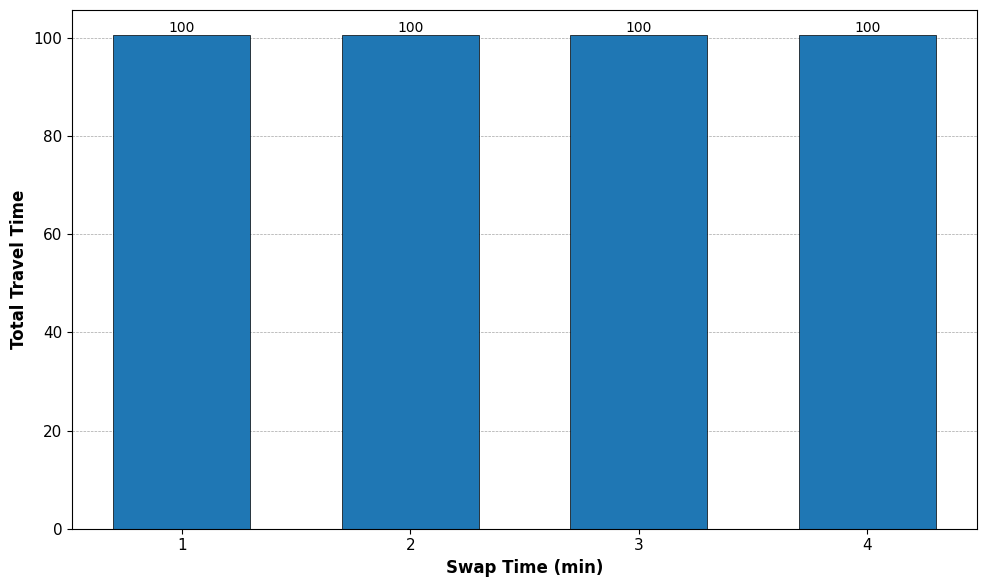

In [20]:
# Swap Time - Travel Time
fig, ax = create_simple_bar_chart(
    df_swaptime,
    'Swap Time (min)',
    'Total Travel Time',
    ylabel='Total Travel Time'
)
plt.show()

## (b) Energy

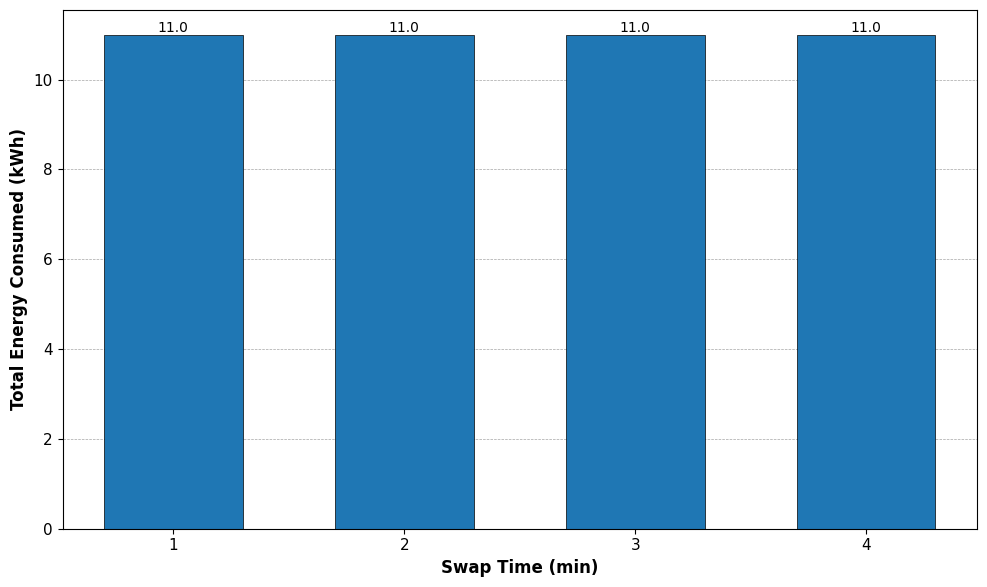

In [21]:
# Swap Time - Total Energy Consumed
fig, ax = create_simple_bar_chart(
    df_swaptime,
    'Swap Time (min)',
    'Total Energy Consumed',
    ylabel='Total Energy Consumed (kWh)'
)
plt.show()

## (c) Distance

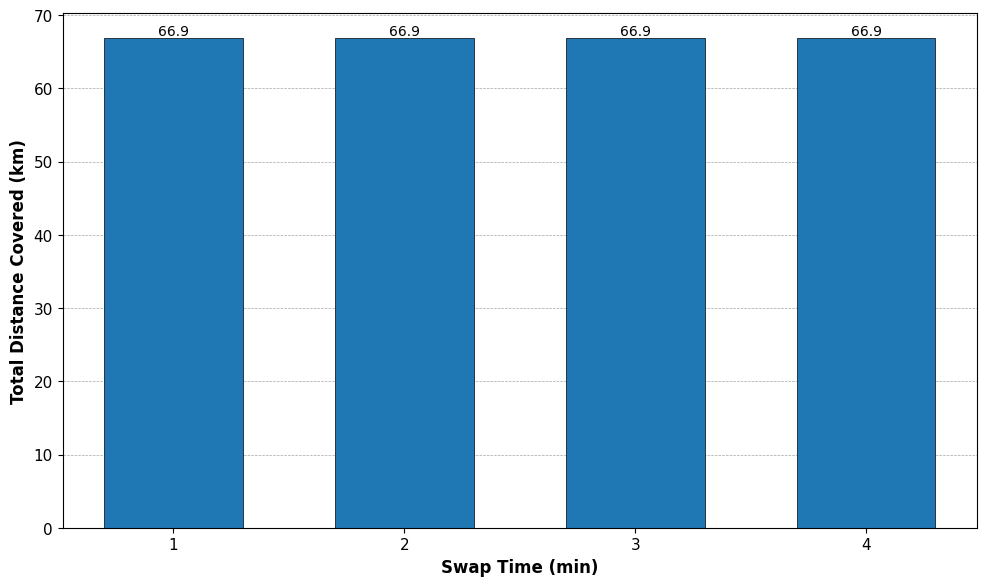

In [22]:
# Swap Time - Total Distance Covered
fig, ax = create_simple_bar_chart(
    df_swaptime,
    'Swap Time (min)',
    'Total Distance Covered',
    ylabel='Total Distance Covered (km)'
)
plt.show()

## (d) Run Time

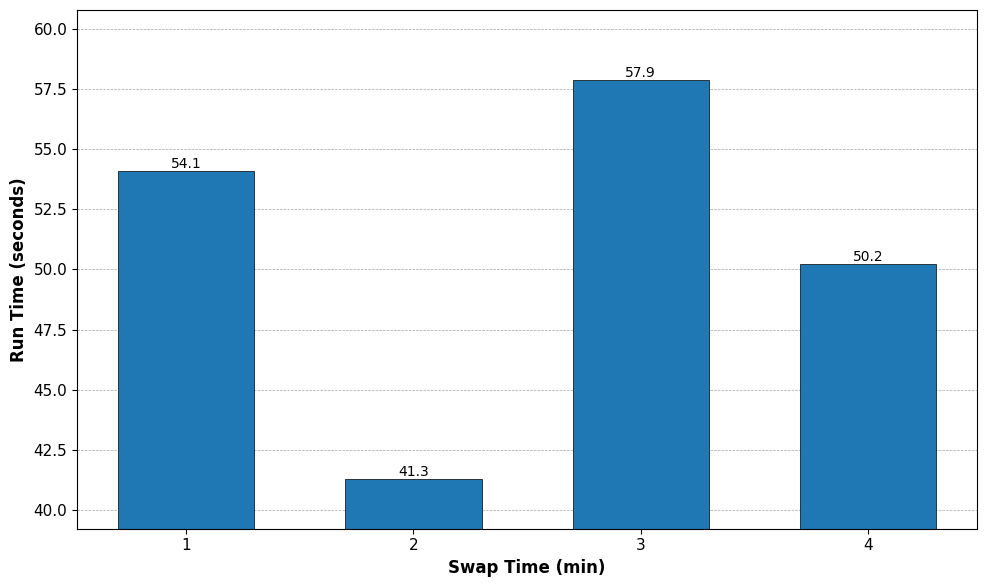

In [23]:
# Swap Time - Run Time
fig, ax = create_simple_bar_chart(
    df_swaptime,
    'Swap Time (min)',
    'Run Time',
    ylabel='Run Time (seconds)'
)
plt.show()